# A Rough Derivation of the Multilayer Perceptron 
---
## Intro
I came across a really exciting theorem: the Universal Approximation Theorem, which roughly states that neural networks can approximate any function to any desired degree of accuracy. I've always enjoyed learning things from the ground up, so before using any modern deep learning frameworks to tackle problems in my field I wanted to build a neural network from scratch. Below, I derive a simple multilayer perceptron, implement it in NumPy, then train and test using the MNIST dataset to produce a model that can classify handwritten digits with $\sim 97 \%$ accuracy.

## Derivation
### 1. Structural Overview
The multilayer perceptron (MLP) can be visualized as a directed acyclic graph (DAG) composed of $L$ vertical layers of neurons, where each neuron in a given layer is connected to every neuron in the next layer. The data enters the input layer, flows forward through the hidden layers, and out through the output layer producing the prediction(s).

### 2. Forward Propagation and Loss
The activation value of a neuron in some layer $l$, denoted $a^{[l]}_{i}$, is given by some non-linear activation function, $g^{[l]}(\cdot)$ on the pre-activation value, $z^{[l]}_{i}$, which is given by a weighted sum of the activations in the previous layer plus a bias term, $b^{[l]}_i$. Notice, the point-wise nonlinearity is essential or the entire network would collapse to a simple linear function. Consider the two specific cases of the activation at the first, $l=0$, and last layer, $l=L-1$, in the network. The activation at the first layer $a^{[0]}_{i}$ is equal to the input $x_i$. The activation at the last layer will depend on the desired behavior of the network; the task at hand is a classification, therefore, the softmax activation function will be used for $g^{[L-1]}(\cdot)$ in tandem with the categorical cross entropy loss function. The softmax activation function transforms the elements of a vector into a probability distribution whose elements sum to $1$ and are bounded in $[0,1]$. This pairing is perfect because the output of softmax will be interpreted as a probability distribution of prediction confidence over the classes and the categorical cross entropy loss function measures the discrepancy between two probability distributions and punishes accordingly. Thus, the general forward pass for $l \in \{ 1, 2, \cdots, L-2\}$ and $M$ classes may be expressed in scalar operations as:
$$
\begin{aligned}
a^{[0]}_{i} &= x_{i} \\ 
z^{[l]}_{i} &= \sum_{j}w^{[l]}_{ij}a^{[l-1]}_{j} + b^{[l]}_{i} \\
a^{[l]}_{i} &= g^{[l]}(z^{[l]}_{i}) = \text{ReLU}(z^{[l]}_{i}) = \max(0, z^{[l]}_{i}) \\
a^{[L-1]}_{i} &= \text{softmax}(\mathbf{z}^{[L-1]})_i = \frac{\exp({z^{[L-1]}_{i}})}{\sum_{k}{\exp({z^{[L-1]}_{k}})}}\\
\mathcal{L}_{\text{cce}} &= -\sum^{M}_{m} y_{m}\ln(a^{[L-1]}_{m})
\end{aligned}
$$

Expressing the neural network as scalar operations is a great intuition builder, but it severely under-leverages modern hardware architecture and libraries such as NumPy which can achieve blistering speed by parallelizing vectorized operations. Additionally, modern datasets are often massive and consequently must be to be split into batches for training. Therefore, the notation, implementation, and wall clock performance may be improved by vectorizing the above for a batch size of $N$ as:
$$
\begin{aligned}
\mathbf{A}^{[0]}&= \mathbf{X} \\
\mathbf{Z}^{[l]} &= \mathbf{W}^{[l]}\mathbf{A}^{[l-1]} + \mathbf{b}^{[l]} \\
\mathbf{A}^{[l]} &= \mathbf{ReLU}(\mathbf{Z}^{[l]}) \\
\mathbf{A}^{[L-1]} &= \mathbf{softmax}(\mathbf{Z}^{[L-1]}) \\
\mathcal{L}_{\text{cce}} &= -\frac{1}{N}\sum^{N}_{n=1}\sum^{M}_{m=1} y_{mn}\ln(a^{[L-1]}_{mn})
\end{aligned}
$$
with matrices:
$$
\begin{aligned}
    \mathbf{A}^{[l]} &\in \mathbb{R}^{n_l \times N}\\
    \mathbf{W}^{[l]} &\in \mathbb{R}^{n_l \times n_{l-1}}\\
    \mathbf{b}^{[l]} &\in \mathbb{R}^{n_l \times 1} \\
\end{aligned}
$$
where each column of $\mathbf{A}^{[l]}$ corresponds to a training example.

### 3. Backward Propagation and Gradient Descent
At this point, the model can produce predictions and the performance can be measured, but these predictions are completely naive and the model cannot learn. The model must change its parameters with respect to the loss function in order to achieve better performance, i.e. it must learn.

A very elegant method is gradient descent, a calculus-based optimization technique that updates the parameters using the gradient composed of the partial derivatives of the parameters with respect to the loss function. It provides a clean way of determining exactly how much each weight, bias, pre-activation, and activation affects the loss. Notice that the successful implementation of gradient descent relies on differentiation; now, observe that neural networks may be expressed as composite functions and, subsequently, differentiated using the chain rule (given the composing functions are differentiable). In practice, this differentiation is not done by hand, instead it is achieved using a dynamic programming-based numerical technique called automatic differentiation. The reader may find it helpful to visualize backpropagation as walking backwards through the network, determining how much each activation, pre-activation, weight, and bias affects the loss. Let: 
$$\theta = \{\mathbf{W}^{[1]},\mathbf{b}^{[1]}, \ldots, \mathbf{W}^{[L-1]},\mathbf{b}^{[L-1]} \}$$
denote the parameter set and
$$
\nabla_{\theta}\mathcal{L} = \left\{ \frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{W}^{[1]}}, \frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{b}^{[1]}},\cdots, \frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{W}^{[L-1]}}, \frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{b}^{[L-1]}} \right\}
$$
denote the corresponding gradient.

Thus, the parameter set will be updated according to: $\theta_{t+1} = \theta_{t} - \eta (\nabla_{\theta}\mathcal{L})_t$, where $\eta$ denotes the learning rate. Note, while there are several types of gradient descent to choose from, mini-batch is used as steps are being taken in the parameter space based on the gradient of a random subset (or batch) of the full training dataset.

The first question when propagating error backwards through the network is "how does the change in some $z^{[L-1]}_j$ affect all $a^{[L-1]}_i$ and how does that affect $\mathcal{L}_{\text{cce}}$?". Posing this question as a derivative yields:
$$
\frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[L-1]}_j} = \sum_i \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a^{[L-1]}_i} \frac{\partial a^{[L-1]}_i}{\partial z^{[L-1]}_j}
$$
As it is clear which derivative is being taken the layer indexing will be temporarily dropped to keep the notation clean.

#### 3.1 $\frac{\partial \mathcal{L}_{\text{cce}}}{\partial a_i}$ Derivative of The Loss With Respect to Softmax
$$
\begin{aligned}
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a_i} &= \frac{\partial}{\partial a_i} \left[- \sum_i y_i \ln(a_i) \right] \\
    &= -\frac{y_i}{a_i}
\end{aligned}
$$

#### 3.2 $\frac{\partial a_i}{\partial z_j}$ Derivative of Softmax With Respect to The Pre-Activation
##### Case 1: $i = j$
$$
\begin{aligned}
    \frac{\partial a_i}{\partial z_i} &= \frac{\partial}{\partial z_i} \left[ \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right] \\
    &= \frac{\frac{\partial}{\partial z_i} \left[\exp(z_i)\right] \sum_k\exp(z_k) - \exp(z_i) \frac{\partial}{\partial z_i} \left[\sum_k\exp(z_k) \right]}{\left( \sum_k \exp(z_k)\right)^2} \qquad \because \text{Quotient Rule.} \\
    &= \frac{\exp(z_i) \sum_k\exp(z_k) - \exp(z_i)\exp(z_i)}{\left( \sum_k \exp(z_k)\right)^2} \\
    &= \left( \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right) \left( \frac{\sum_k \exp(z_k) - \exp(z_i)}{\sum_k \exp(z_k)} \right) \\
    &= \left( \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right) \left( \frac{\sum_k \exp(z_k)}{\sum_k \exp(z_k)} -  \frac{ \exp(z_i)}{\sum_k \exp(z_k)}\right) \\
    &= a_i (1 - a_i)
\end{aligned}
$$
##### Case 2: $i \ne j$
$$
\begin{aligned}
    \frac{\partial a_i}{\partial z_j} &= \frac{\partial}{\partial z_j} \left[ \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right] \\
    &= \frac{\frac{\partial}{\partial z_j} \left[\exp(z_i)\right] \sum_k\exp(z_k) - \exp(z_i) \frac{\partial}{\partial z_j} \left[\sum_k\exp(z_k) \right]}{\left( \sum_k \exp(z_k)\right)^2} \qquad \because \text{Quotient Rule.} \\
    &= \frac{0(\sum_k \exp(z_k)) - \exp(z_i) \exp(z_j)}{\left( \sum_k \exp(z_k)\right)^2} \\
    &= \frac{- \exp(z_i) \exp(z_j)}{\left( \sum_k \exp(z_k)\right)^2} \\
    &= -\left( \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right)\left( \frac{\exp(z_j)}{\sum_k \exp(z_k)} \right) \\
    &= - a_i a_j
\end{aligned}
$$ 
Now combining the above:
$$
\begin{aligned}
    \implies \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z_j} &= \sum_{i \ne j}\left( - \frac{y_i}{a_i} \right)(-a_i a_j) + \left( - \frac{y_j}{a_j} \right)a_j (1 - a_j) \\
    &= \sum_{i \ne j}\frac{y_i a_i a_j}{a_i} + \left( - \frac{y_j a_j (1 - a_j)}{a_j} \right) \\
    &= \sum_{i \ne j} y_i a_j + y_j a_j - y_j \\
    &= (\sum_{i \ne j} y_i + y_j) a_j - y_j  \\
    &= (1)a_j - y_j \qquad \because \mathbf{y} \text{ is one-hot encoded} \\ 
    &= a_j - y_j 
\end{aligned} 
$$
Thus, we arrive at a delightfully clean result!

#### 3.3 Backpropagating Further
Now define the error signal $\delta^{[l]}_i = \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_i}$ and observe:
$$
\begin{aligned}
    \delta^{[L-1]}_i &= a^{[L-1]}_i - y_i \\
    \implies \mathbf{dZ}^{[L-1]} &= \frac{1}{N} (\mathbf{A}^{[L-1]} - \mathbf{Y}) \qquad \cdot \text{$1/N$ term arises from differentiating the batch loss.}\\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial w^{[l]}_{ij}} &= \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_i} \frac{\partial z^{[l]}_i}{\partial w^{[l]}_{ij}} \\
    &=  \delta^{[l]}_i \frac{\partial}{\partial w^{[l]}_{ij}}\left[w^{[l]}_{i1}a^{[l-1]}_1 + \cdots + w^{[l]}_{ij}a^{[l-1]}_j + \cdots + b^{[l]}_i\right] \\
    &= \delta^{[l]}_i a^{[l-1]}_j \\
    \implies \mathbf{dW}^{[l]} &= \mathbf{dZ}^{[l]} (\mathbf{A}^{[l-1]})^{\top} \qquad \because \text{Computing every $ij$ pair is equivalent to an outer product.} \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a^{[l-1]}_{j}} &= \sum_{i} \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_{i}} \frac{\partial z^{[l]}_{i}}{\partial a^{[l-1]}_{j}} \\
    &= \sum_i \delta^{[l]}_i \frac{\partial}{\partial a^{[l-1]}_{j}}\left[w^{[l]}_{i1}a^{[l-1]}_1 + \cdots + w^{[l]}_{ij}a^{[l-1]}_j + \cdots + b^{[l]}_i\right] \\
    &= \sum_i \delta^{[l]}_i w^{[l]}_{ij} \\
    \implies \mathbf{dA}^{[l-1]} &= (\mathbf{W}^{[l]})^{\top} \mathbf{dZ}^{[l]} \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l-1]}_{j}} &= \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a^{[l-1]}_{j}} \frac{\partial a^{[l-1]}_j}{\partial z^{[l-1]}_{j}} \\
    &= \sum_i \delta^{[l]}_i w^{[l]}_{ij} \text{ReLU}'(z^{[l-1]}_{j}) \\
    \text{With: } &\text{ReLU}'(z) := \begin{cases} 1 \quad \text{if} \quad z > 0 \\
    0 \quad \text{if} \quad z \le 0\end{cases} \qquad \cdot \text{Let RelU}'(0) = 0 \text{ despite it being technically undefined.}\\
    \implies \mathbf{dZ}^{[l-1]} &= ((\mathbf{W}^{[l]})^{\top} \mathbf{dZ}^{[l]}) \mathbf{\odot} \mathbf{ReLU}'(\mathbf{Z}^{[l-1]}) = \mathbf{dA}^{[l-1]} \mathbf{\odot} \mathbf{ReLU}'(\mathbf{Z}^{[l-1]}) \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial b^{[l]}_i} &=  \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_{i}}  \frac{\partial z^{[l]}_{i}}{\partial b^{[l]}_{i}} \\
    &= \delta^{[l]}_i(1) \\ 
    &= \delta^{[l]}_i \\
    \implies \mathbf{db}^{[l]} &= \sum^{N}_{n=1} \mathbf{dZ}^{[l]}_{:,n}  
\end{aligned}
$$

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [28]:
# Define an RNG

rng = np.random.default_rng(seed=42)

In [29]:
# Load in MNIST dataset

fp = "mnist.csv"
df = pd.read_csv(fp)
df.reset_index(drop=True, inplace=True)
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [30]:
# Transpose and inspect

df = df.T
df

,0,1,2,3,4,5,6,7,8,9,...,41990,41991,41992,41993,41994,41995,41996,41997,41998,41999
label,1,0,1,4,0,0,7,3,5,3,...,3,1,9,6,4,0,1,7,6,9
pixel0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel780,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel781,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
df.to_numpy()[0:3, ]

array([[1, 0, 1, ..., 7, 6, 9],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 42000))

In [32]:
# Perturb and create train-test split

ds = df.to_numpy()
ds = rng.permutation(ds, axis=1)        # Perturb matrix columns

assert np.isnan(ds).sum() == 0      # No NaNs!!!

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

m, n = ds.shape
X_train = normalize(ds[1: ,0:int(0.75*n)])
Y_train = ds[0,0:int(0.75*n)]

X_test = normalize(ds[1: ,int(0.75*n): ])
Y_test = ds[0,int(0.75*n): ]

Y_train_one_hot = np.eye(10)[Y_train].T
Y_test_one_hot = np.eye(10)[Y_test].T


print(X_train.shape, Y_train_one_hot.shape, X_test.shape, Y_test_one_hot.shape)

(784, 31500) (10, 31500) (784, 10500) (10, 10500)


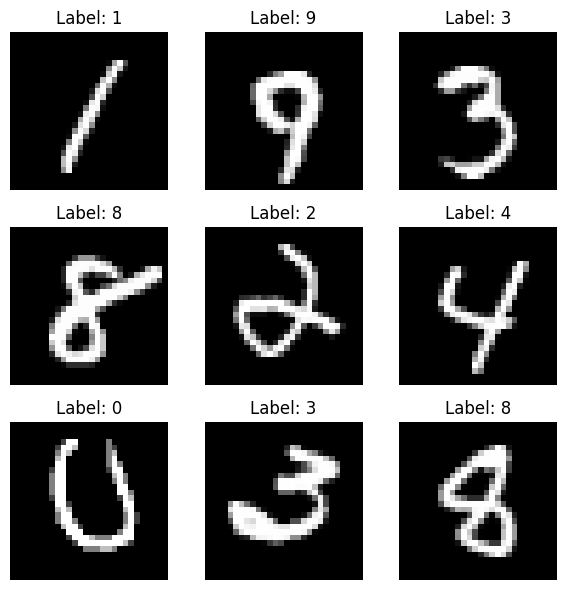

In [33]:
# Create a 3x3 grid and plot digits and their corresponding labels

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()

for i in range(9):
    # Pick a random index from the training set
    idx = rng.integers(0, X_train.shape[1])
    
    # Reshape the flat 784 pixels back into a 28x28 image
    img = X_train[:,idx].reshape(28, 28)
    
    # Plot the image
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {Y_train[idx]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Define model

def relu(Z):
    return np.maximum(0, Z)     # element-wise

def relu_prime(Z):
    return (Z > 0).astype(int)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def cce(Y_hat, Y):
    eps = 1e-15
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    return -np.mean(np.sum(Y * np.log(Y_hat), axis=0))

def forward(
        X,
        W1, b1,
        W2, b2,
        W3, b3
):
    A0 = X
    
    Z1 = W1 @ A0 + b1       # b1 is broadcast
    A1 = relu(Z1)

    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)

    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)

    return {
        "A3":A3, "Z3":Z3,
        "A2":A2, "Z2":Z2, 
        "A1":A1, "Z1":Z1, 
        "A0":A0,
        "W3":W3, "b3":b3,
        "W2":W2, "b2":b2,
        "W1":W1, "b1":b1
    }


def backward(cache, Y, N):
    A3     = cache["A3"]
    A2, Z2 = cache["A2"], cache["Z2"]
    A1, Z1 = cache["A1"], cache["Z1"]
    A0     = cache["A0"]
    W3     = cache["W3"]
    W2     = cache["W2"]

    dZ3 = (A3 - Y) / N
    dW3 = dZ3 @ A2.T
    db3 = np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = (W3.T @ dZ3) * relu_prime(Z2)     # element-wise product (Hadamard product) 
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = (W2.T @ dZ2) * relu_prime(Z1)
    dW1 = dZ1 @ A0.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    return {
        "dW1":dW1, "db1":db1,
        "dW2":dW2, "db2":db2,
        "dW3":dW3, "db3":db3    
    }

In [9]:
# Train!
N = 150     # batch size
ada = 0.1   # learning rate
epochs = 50

loss_history = []
accuracy_history = []

# init weigths and biases
# scale by sqrt(2 / neurons_in)
W1 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 784), size=(64, 784))
b1 = np.zeros((64, 1))

W2 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 64), size=(64, 64))
b2 = np.zeros((64, 1))

W3 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 64), size=(10, 64))
b3 = np.zeros((10, 1))

for epoch in tqdm(range(epochs)):
    epoch_loss = 0
    correct_predictions = 0
    total_samples = X_train.shape[1]
    
    for i in range(0, X_train.shape[1], N):
        cache = forward(
            X_train[ : ,i:i+N],
            W1, b1,
            W2, b2,
            W3, b3        
        )

        grads = backward(cache, Y_train_one_hot[ : ,i:i+N], N)

        W1 -= ada*grads["dW1"]
        b1 -= ada*grads["db1"]

        W2 -= ada*grads["dW2"]
        b2 -= ada*grads["db2"]

        W3 -= ada*grads["dW3"]
        b3 -= ada*grads["db3"]

    # Metric run
    full_cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    
    # Calculate CCE loss
    current_loss = cce(full_cache["A3"], Y_train_one_hot)
    loss_history.append(current_loss)
    
    # Calculate accuracy 
    predictions = np.argmax(full_cache["A3"], axis=0)
    targets = np.argmax(Y_train_one_hot, axis=0)
    current_accuracy = np.mean(predictions == targets) * 100
    accuracy_history.append(current_accuracy)
    

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [05:01<00:00,  6.04s/it]


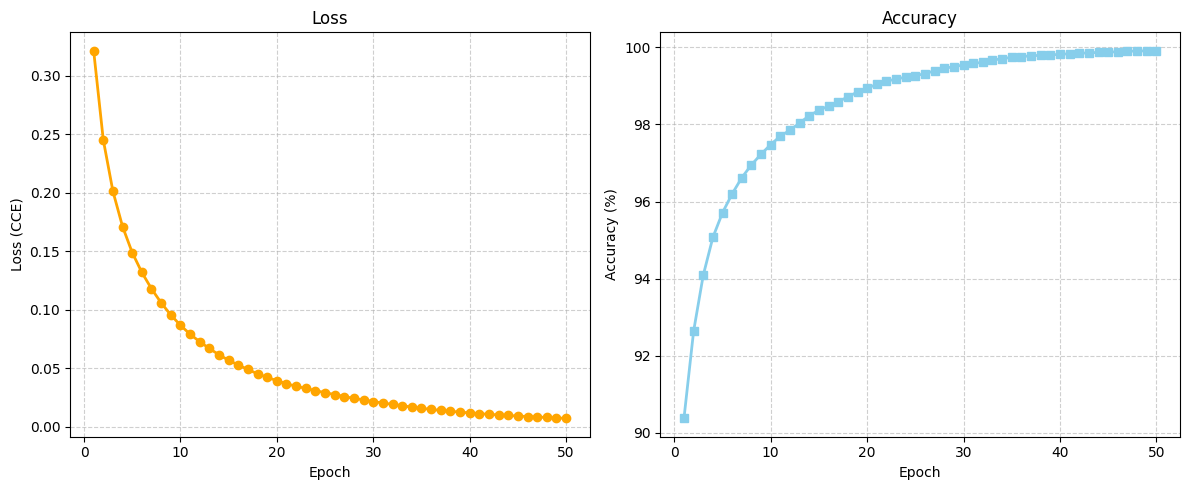

In [15]:
# Plot training performance

plt.figure(figsize=(12, 5))

# Plot CCE Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_history, marker="o", color="orange", linewidth=2)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (CCE)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), accuracy_history, marker="s", color="skyblue", linewidth=2)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [35]:
# Test on test set

test_cache = forward(X_test, W1, b1, W2, b2, W3, b3)

test_loss = cce(test_cache["A3"], Y_test_one_hot)

predictions = np.argmax(test_cache["A3"], axis=0)
targets = np.argmax(Y_test_one_hot, axis=0)
test_accuracy = np.mean(predictions == targets) * 100
print(f"Test set accuracy: {test_accuracy:.2f}%")

Test set accuracy: 97.02%


Total misclassifications in test set: 313 out of 10500


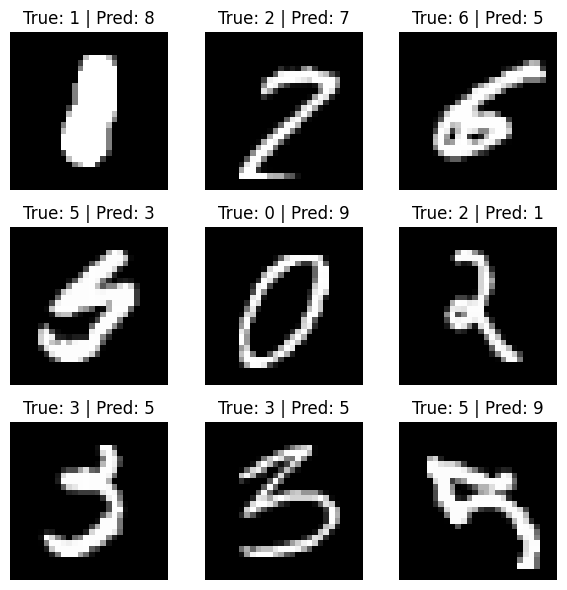

In [34]:
# Plot a few examples of incorrect digit classifications

incorrect_indices = np.where(predictions != targets)[0]

print(f"Total misclassifications in test set: {len(incorrect_indices)} out of {len(targets)}")


plt.figure(figsize=(6, 6))

# Get first 9 misclassified
for idx, test_idx in enumerate(incorrect_indices[:9]):
    plt.subplot(3, 3, idx + 1)
    
    digit_image = X_test[:, test_idx].reshape(28, 28)
    
    # Plot image
    plt.imshow(digit_image, cmap='gray')
    
    # Extract the string representation of target vs prediction
    true_label = targets[test_idx]
    pred_label = predictions[test_idx]
    
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Conclusion
The model achieved $\sim 97 \%$ accuracy despite a relatively simple architecture! This derivation and implementation has deepened my own understanding and appreciation of neural networks and the research that goes into creating some of the prominent architectures that drive automation, insight, and innovation in today's society.